In [1]:
from ultralytics import YOLO
import rasterio
import matplotlib.pyplot as plt
import numpy as np
from piq import KID
import torch
import os
from glob import glob
import random


def read_image(path):
    with rasterio.open(path) as src:
        image = src.read()
    return image[:3].transpose(1, 2, 0)  # Convert to HWC format

    
def match_histogram(source, target):
    matched = np.zeros_like(source)
    for c in range(source.shape[2]):
        src_band = source[:, :, c].flatten()
        tgt_band = target[:, :, c].flatten()

        src_values, src_counts = np.unique(src_band, return_counts=True)
        tgt_values, tgt_counts = np.unique(tgt_band, return_counts=True)

        src_cdf = np.cumsum(src_counts).astype(np.float64) / src_counts.sum()
        tgt_cdf = np.cumsum(tgt_counts).astype(np.float64) / tgt_counts.sum()

        interp_tgt_values = np.interp(src_cdf, tgt_cdf, tgt_values)
        matched[:, :, c] = np.interp(src_band, src_values, interp_tgt_values).reshape(source[:, :, c].shape)

    return matched.astype(source.dtype)


def percentile_stretch(image, lower=0, upper=99.99):
    stretched = np.zeros_like(image)
    for c in range(image.shape[2]):
        # do not consider 0 values for percentile calculation
        non_zero_pixels = image[:, :, c][image[:, :, c] > 0]
        if len(non_zero_pixels) == 0:
            stretched[:, :, c] = image[:, :, c]
            continue

        p_low, p_high = np.percentile(non_zero_pixels, [lower, upper])
        stretched[:, :, c] = np.clip((image[:, :, c] - p_low) * 255.0 / (p_high - p_low), 0, 255)

    return stretched.astype(np.uint8)


def delete_non_data(tile, threshold=0.05):
    """
    Returns True if the tile contains valid data, False if it is mostly 'No Data'.
    """   
    no_data_pixels = np.all(tile == 0, axis=-1)
    no_data_fraction = np.mean(no_data_pixels)
    
    return no_data_fraction < threshold


def is_single_color(tile, tolerance=20):
    """
    Returns True if the tile lacks texture (e.g., empty ocean, flat clouds, or black padding).
    Works by checking if (Max - Min) < tolerance for EVERY color channel.
    """
    # 1. Find the min and max values for each channel (R, G, B)
    # Cast to int16 to safely subtract without uint8 underflow issues
    min_vals = np.min(tile, axis=(0, 1)).astype(np.int16)
    max_vals = np.max(tile, axis=(0, 1)).astype(np.int16)
    
    # 2. Calculate the spread (max - min) for each channel
    spread = max_vals - min_vals
    
    # 3. Return True ONLY if all channels have a spread less than the tolerance
    return np.all(spread < tolerance)


def cut_into_tiles(image, tile_size=64):
    tiles = []
    for i in range(0, image.shape[0], tile_size):
        for j in range(0, image.shape[1], tile_size):
            tile = image[i:i+tile_size, j:j+tile_size, :]
            
            # Check for correct dimensions
            if tile.shape[0] == tile_size and tile.shape[1] == tile_size:
                # Filter 1: Does it have too much NoData?
                if delete_non_data(tile):
                    # Filter 2: Is it just a solid block of a single color?
                    if not is_single_color(tile):
                        tiles.append(tile)
                    
    print(f"Cut image into {len(tiles)} tiles of size {tile_size}x{tile_size} (discarded empty/solid areas)")
    return np.array(tiles)


def extract_yolo_features(tiles, model):
    embeddings = []
    for tile in tiles:
        results = model.embed(tile, imgsz=640)
        embeddings.append(results[0].cpu().numpy())
        print(f"Extracted features from tile {len(embeddings)}/{len(tiles)}")  
    return embeddings

In [2]:
def plot_matrix(matrix, labels, title="", precision=2):
    plt.figure(figsize=(14, 10))
    plt.imshow(matrix, cmap="viridis", vmin=np.min(matrix), vmax=np.max(matrix))
    plt.colorbar()
    plt.xticks(range(len(labels)), labels, rotation=45)
    plt.yticks(range(len(labels)), labels)
    mean_val = np.mean(matrix)
    for i in range(len(labels)):
        for j in range(len(labels)):
            plt.text(j, i, f"{matrix[i, j]:.{precision}f}", ha="center", va="center", color="white" if matrix[i, j] < mean_val else "black")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def compute_mean_scores(results, dataset_names, prefix="S2"):
    mean_scores = {}
    for i, name_i in enumerate(dataset_names):
        mean_scores[name_i] = np.mean([results[i, j] for j, name_j in enumerate(dataset_names) if name_j.startswith(prefix) and j != i])
    return mean_scores

In [3]:
import torchvision.transforms as T
from transformers import AutoModel
from transformers.modeling_utils import PreTrainedModel
from PIL import Image




# SatDINO: DINO pretrained on fMoW satellite imagery (strakaj/SatDINO)
# Options: strakajk/satdino-vit_small-16 | strakajk/satdino-vit_small-8 | strakajk/satdino-vit_base-16
SATDINO_MODEL = "strakajk/satdino-vit_base-16" 

# fMoW normalization stats (as used in SatDINO training)
FMOW_MEAN = (0.3826, 0.3525, 0.3051)
FMOW_STD  = (0.1598, 0.1474, 0.1384)

def _get_all_tied_weights_keys(self):
    val = getattr(self, "_tied_weights_keys", None)
    if val is None:
        return {}
    return val
PreTrainedModel.all_tied_weights_keys = property(_get_all_tied_weights_keys)


def build_satdino_transform():
    """
    Preprocessing transform expected by SatDINO:
    resize to 224x224, convert to float tensor [0,1], normalize with fMoW stats.
    """
    return T.Compose([
        T.Resize((224, 224)),
        T.ToTensor(),                        # (H,W,3) uint8 -> (3,H,W) float [0,1]
        T.Normalize(mean=FMOW_MEAN, std=FMOW_STD),
    ])

def tile_to_rgb_uint8(tile):
    """
    Convert a (C, H, W) multi-band tile to a (H, W, 3) uint8 RGB image
    using bands 0, 1, 2 with 2-98% percentile stretch.
    """
    if tile.shape[0] >= 3:
        rgb = tile[:3].astype(np.float32)
    else:
        rgb = np.stack([tile[0].astype(np.float32)] * 3)

    # normalize using mean and std

    stretched = np.zeros((3,) + rgb.shape[1:], dtype=np.uint8)
    for c in range(3):
        band = rgb[c]
        p2, p98 = np.percentile(band, 0), np.percentile(band, 100)
        if p98 > p2:
            band = (band - p2) / (p98 - p2)
            # band = band / 255.0
        else:
            band = band - band.min()
            if band.max() > 0:
                band = band / band.max()
        stretched[c] = np.clip(band * 255, 0, 255).astype(np.uint8)
    
    return np.transpose(stretched, (1, 2, 0))  # (H, W, 3)

def extract_satdino_features(tiles, batch_size=32):
    """
    Extract per-tile CLS token embeddings using strakaj/SatDINO.

    Args:
        tiles:      (N, C, H, W) numpy array of multi-band raw tiles
        batch_size: tiles to process in one forward pass

    Returns:
        features:   (N, embed_dim) numpy array  -- 384-d for ViT-S
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = AutoModel.from_pretrained(SATDINO_MODEL, trust_remote_code=True)
    model.to(device)
    model.eval()

    transform = build_satdino_transform()
    all_features = []

    for start in range(0, len(tiles), batch_size):
        batch_tiles = tiles[start:start + batch_size]

        # Convert each raw tile -> uint8 RGB PIL image -> transformed tensor
        tensors = []
        for tile in batch_tiles:
            rgb_uint8 = tile_to_rgb_uint8(tile)          # (H, W, 3) uint8
            pil_img = Image.fromarray(rgb_uint8, "RGB")
            tensors.append(transform(pil_img))            # (3, 224, 224)

        batch_tensor = torch.stack(tensors).to(device)   # (B, 3, 224, 224)

        with torch.inference_mode():
            # SatDINO forward returns the CLS token: shape (B, embed_dim)
            features = model(batch_tensor)

        all_features.append(features.float().cpu().numpy())

    return np.concatenate(all_features, axis=0)  # (N, embed_dim)

In [4]:
# Parameters
dir_pln = "/home/thomas/Documents/code/pleiades-boat-detection/data/scoring/diff/PLN" # simulé
dir_pl = "/home/thomas/Documents/code/pleiades-boat-detection/data/scoring/diff/PL" # real
tile_size = 128
nb_features = 500

# List images
list_pln = sorted(glob(os.path.join(dir_pln, "**/*.tif"), recursive=True))
list_pl = sorted(glob(os.path.join(dir_pl, "**/*.tif"), recursive=True))

# Cut into tiles - Histogram matching removed
# We now pass the result of read_image(path) directly to cut_into_tiles
pln_tiles = [cut_into_tiles(read_image(path), tile_size) for path in list_pln]
pl_tiles = [cut_into_tiles(read_image(path), tile_size) for path in list_pl]

# Extract features on random tiles from each dataset
all_sampled_tiles = []
pln_features = []
pl_features = []
for tiles in pln_tiles:
    random_tiles = random.sample(list(tiles), min(nb_features, len(tiles)))
    all_sampled_tiles.extend(random_tiles)
    pln_features.append(extract_satdino_features(random_tiles, batch_size=64))
for tiles in pl_tiles:
    random_tiles = random.sample(list(tiles), min(nb_features, len(tiles)))
    all_sampled_tiles.extend(random_tiles)
    pl_features.append(extract_satdino_features(random_tiles, batch_size=64))

Cut image into 31665 tiles of size 128x128 (discarded empty/solid areas)
Cut image into 2412 tiles of size 128x128 (discarded empty/solid areas)
Cut image into 2488 tiles of size 128x128 (discarded empty/solid areas)
Cut image into 9395 tiles of size 128x128 (discarded empty/solid areas)
Cut image into 2803 tiles of size 128x128 (discarded empty/solid areas)
Cut image into 3478 tiles of size 128x128 (discarded empty/solid areas)
Cut image into 39707 tiles of size 128x128 (discarded empty/solid areas)
Cut image into 2905 tiles of size 128x128 (discarded empty/solid areas)
Cut image into 4587 tiles of size 128x128 (discarded empty/solid areas)
Cut image into 76640 tiles of size 128x128 (discarded empty/solid areas)
Cut image into 3253 tiles of size 128x128 (discarded empty/solid areas)
Cut image into 15568 tiles of size 128x128 (discarded empty/solid areas)


Loading weights:   0%|          | 0/151 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/151 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/151 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/151 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/151 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/151 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/151 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/151 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/151 [00:00<?, ?it/s]

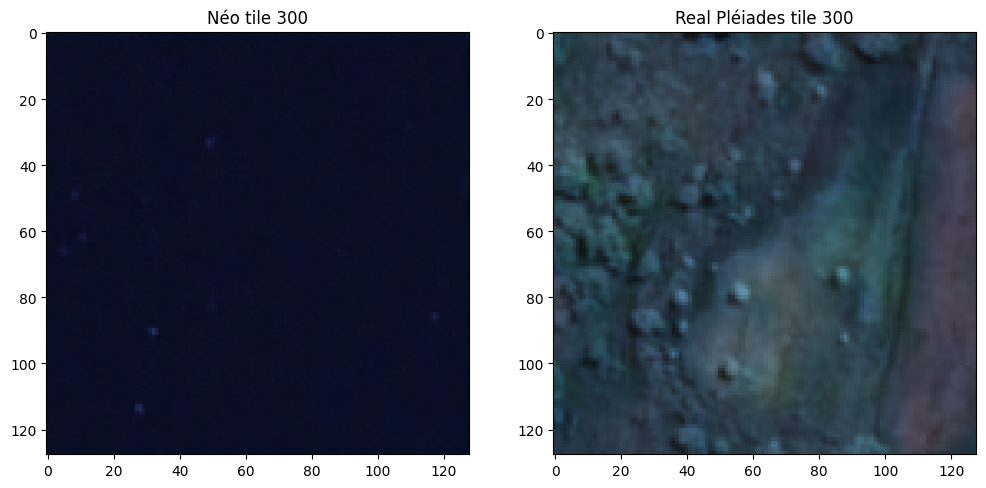

In [5]:
tile_id = 300
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(pln_tiles[0][tile_id])
plt.title(f"Néo tile {tile_id}")
plt.subplot(1,2,2)
plt.imshow(pl_tiles[0][tile_id])
plt.title(f"Real Pléiades tile {tile_id}")
plt.show()

In [6]:
# Prepare datasets for KID computation
datasets = {}
for path, feat in zip(list_pln, pln_features):    # Get filename without extension
    base_name = os.path.splitext(os.path.basename(path))[0]
    datasets[base_name] = feat
    print(f"id: {base_name}\t features: {len(feat)}\t filename: {os.path.basename(path)}")

for i, path in enumerate(list_pl):
    datasets[f"pl_{i}"] = pl_features[i]
    print(f"id: pl_{i}\t features: {len(pl_features[i])}\t filename: {os.path.basename(path)}")




id: Neo_1	 features: 500	 filename: Neo_1.tif
id: Neo_2	 features: 500	 filename: Neo_2.tif
id: Neo_3	 features: 500	 filename: Neo_3.tif
id: simulated_1	 features: 500	 filename: simulated_1.tif
id: simulated_2	 features: 500	 filename: simulated_2.tif
id: simulated_3	 features: 500	 filename: simulated_3.tif
id: pl_0	 features: 500	 filename: PL_1.tif
id: pl_1	 features: 500	 filename: PL_2.tif
id: pl_2	 features: 500	 filename: PL_3.tif
id: pl_3	 features: 500	 filename: PL_4.tif
id: pl_4	 features: 500	 filename: PL_5.tif
id: pl_5	 features: 500	 filename: PL_6.tif


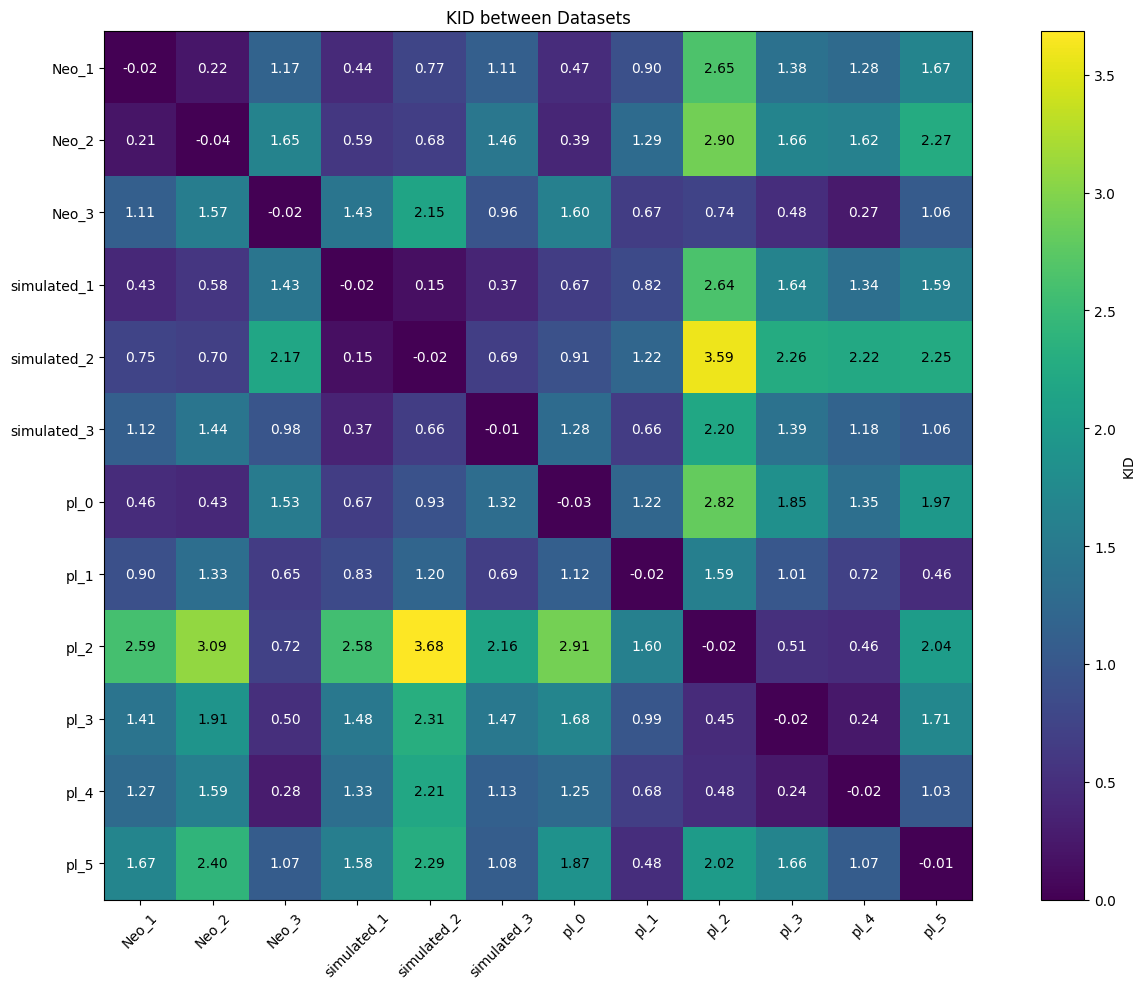


Average KID scores against PL datasets:
Neo_1: 1.3911
Neo_2: 1.6881
Neo_3: 0.8032
simulated_1: 1.4517
simulated_2: 2.0752
simulated_3: 1.2955
pl_0: 1.8388
pl_1: 0.9794
pl_2: 1.5052
pl_3: 1.0136
pl_4: 0.7379
pl_5: 1.4200


In [7]:
# Define KID metric with appropriate parameters
metric = KID(
    degree=3,
    gamma=None,
    coef0=1,
    var_at_m=None,
    average=True,
    n_subsets=50,
    subset_size=100,  # Use 100 random subsets for KID computation
    ret_var=True
)

# Kernel Inception Distance (KID) computation
nb_datasets = len(datasets)
results = np.zeros((nb_datasets, nb_datasets))
for i, (name_i, emb_i) in enumerate(datasets.items()):
    for j, (name_j, emb_j) in enumerate(datasets.items()):
        x_feats = torch.from_numpy(np.array(emb_i)).float()
        y_feats = torch.from_numpy(np.array(emb_j)).float()
        result = metric(x_feats, y_feats)
        # print(f"KID({name_i}, {name_j}) = {result[0].item():.4f} ± {result[1].item():.4f}")
        results[i, j] = result[0].item()  # Store the KID value, ignoring variance


# Visualization
plt.figure(figsize=(14, 10))
plt.imshow(results, cmap="viridis", vmin=0, vmax=np.max(results))
plt.colorbar(label="KID")
plt.xticks(range(nb_datasets), datasets.keys(), rotation=45)
plt.yticks(range(nb_datasets), datasets.keys())
for i in range(nb_datasets):
    for j in range(nb_datasets):
        plt.text(j, i, f"{results[i, j]:.2f}", ha="center", va="center", color="white" if results[i, j] < np.max(results) / 2 else "black")
plt.title("KID between Datasets")
plt.tight_layout()
plt.show()


# get average score for each dataset against all PL datasets except itself
avg_scores = {}
for i, name_i in enumerate(datasets.keys()):
    avg_scores[name_i] = np.mean([results[i, j] for j, name_j in enumerate(datasets.keys()) if name_j.startswith("pl") and j != i])

print("\nAverage KID scores against PL datasets:")
for name, score in avg_scores.items():
    print(f"{name}: {score:.4f}")

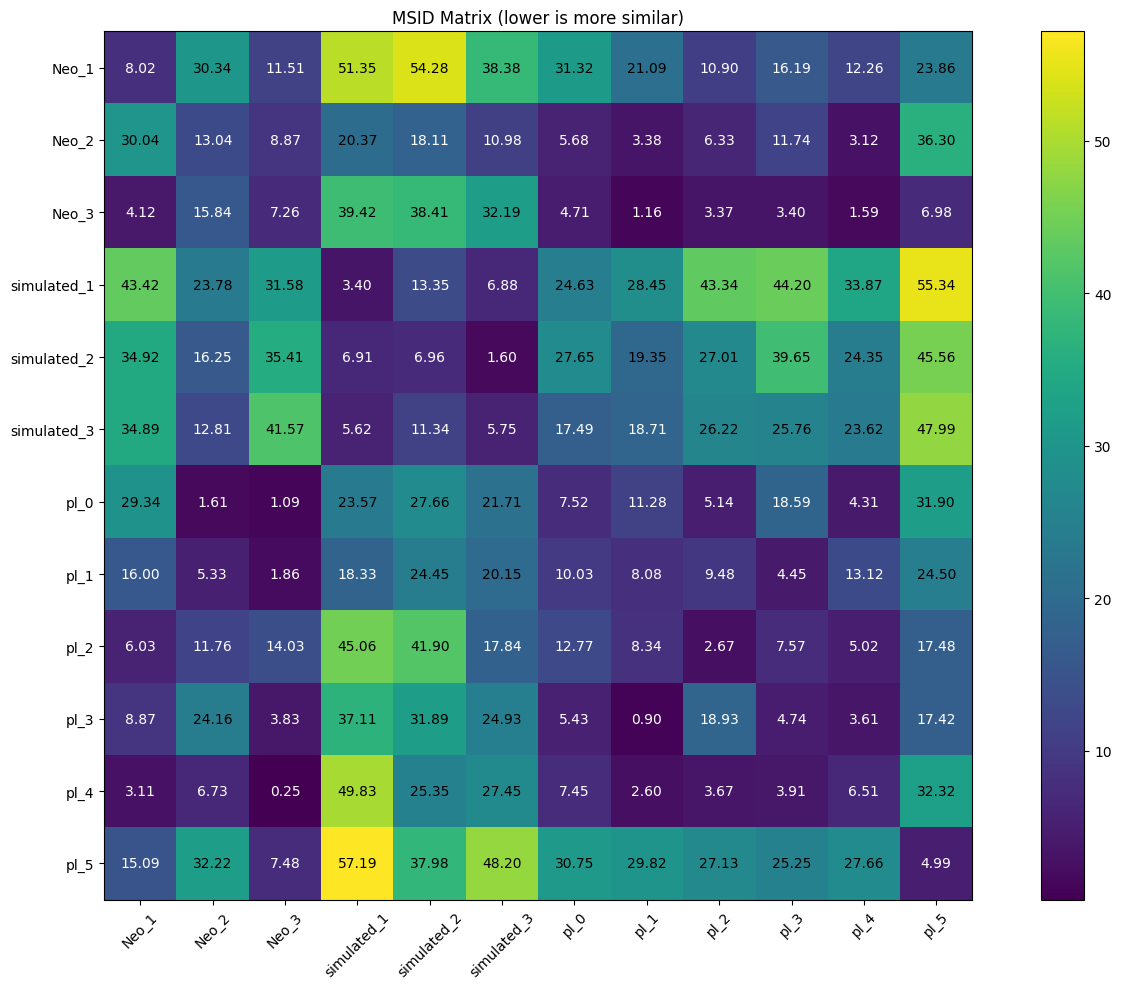

Mean MSID scores against Pléiades datasets:
Neo_1: 19.2686
Neo_2: 11.0907
Neo_3: 3.5338
simulated_1: 38.3063
simulated_2: 30.5942
simulated_3: 26.6335
pl_0: 14.2437
pl_1: 12.3155
pl_2: 10.2347
pl_3: 9.2581
pl_4: 9.9899
pl_5: 28.1232


In [8]:
### MULTI-SCALE INCEPTION DISTANCE (MSID) COMPUTATION

from piq import MSID
dataset_names = list(datasets.keys())

# Define MSID metric with appropriate parameters
msid_metric = MSID()
# MSID computation
msid_results = np.zeros((nb_datasets, nb_datasets))
for i, (name_i, emb_i) in enumerate(datasets.items()):
    for j, (name_j, emb_j) in enumerate(datasets.items()):
        x_feats = torch.from_numpy(np.array(emb_i)).float()
        y_feats = torch.from_numpy(np.array(emb_j)).float()
        result = msid_metric(x_feats, y_feats)
        msid_results[i, j] = result.item()  # Store the MSID value

plot_matrix(msid_results, dataset_names, title="MSID Matrix (lower is more similar)", precision=2)

mean_msid_scores = compute_mean_scores(msid_results, dataset_names, prefix="pl")
print("Mean MSID scores against Pléiades datasets:")
for name, score in mean_msid_scores.items():
    print(f"{name}: {score:.4f}")

/home/thomas/miniconda3/envs/sam3_env/lib/python3.12/site-packages/piq/isc.py:45: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  probas = F.softmax(features)


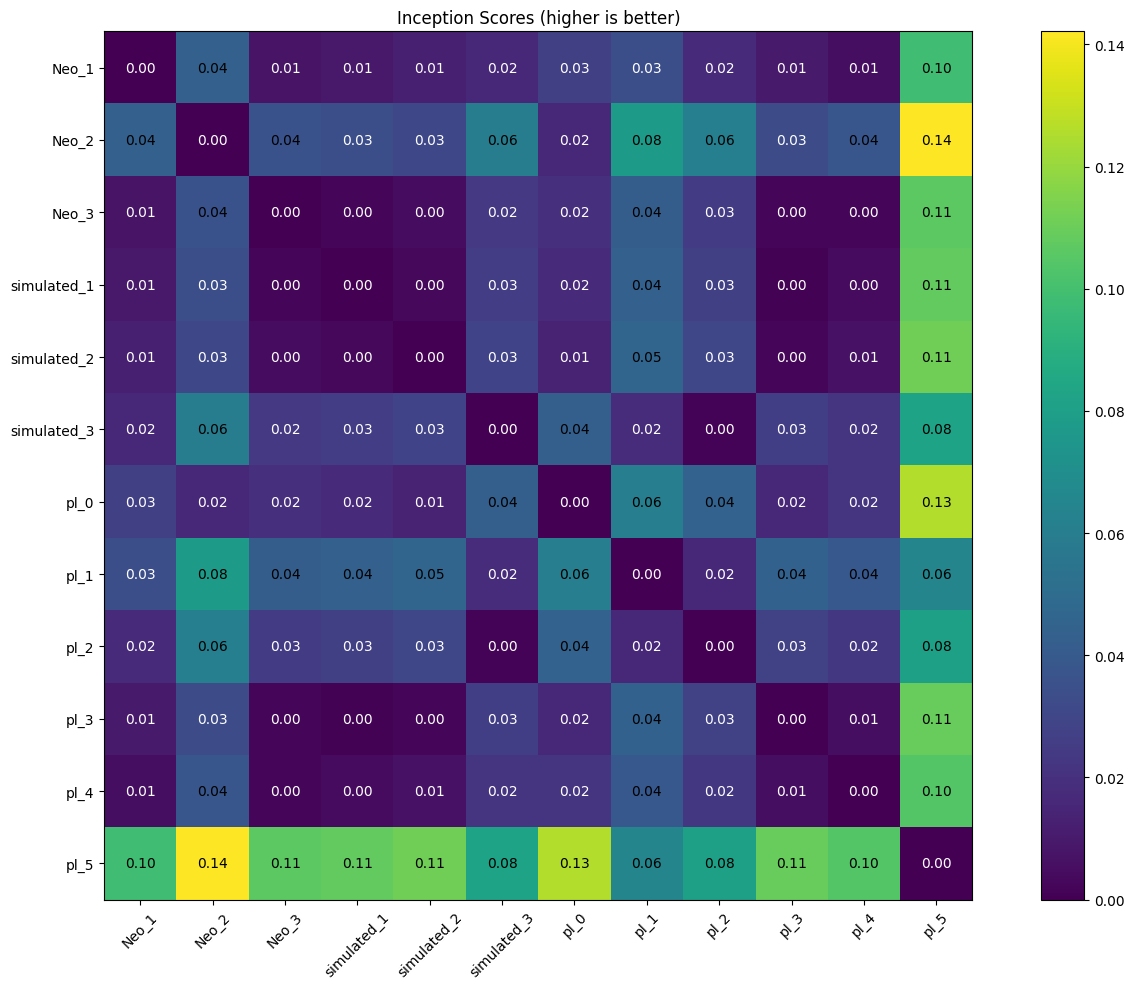

Mean Inception Scores against Pléiade datasets:
Neo_1: 0.0322
Neo_2: 0.0614
Neo_3: 0.0329
simulated_1: 0.0336
simulated_2: 0.0353
simulated_3: 0.0322
pl_0: 0.0538
pl_1: 0.0451
pl_2: 0.0386
pl_3: 0.0406
pl_4: 0.0386
pl_5: 0.0969


In [9]:
### INCEPTION SCORE (IS) COMPUTATION

from piq import IS

# Define IS metric with appropriate parameters
is_metric = IS()
# IS computation
is_results = np.zeros((nb_datasets,nb_datasets))  # Store IS values for each dataset
for i, (name_i, emb_i) in enumerate(datasets.items()):
    for j, (name_j, emb_j) in enumerate(datasets.items()):
        x_feats = torch.from_numpy(np.array(emb_i)).float()
        y_feats = torch.from_numpy(np.array(emb_j)).float()
        result = is_metric(x_feats, y_feats)
        is_results[i, j] = result.item()  # Store the IS value

plot_matrix(is_results, dataset_names, title="Inception Scores (higher is better)", precision=2)

mean_is_scores = compute_mean_scores(is_results, dataset_names, prefix="pl")
print("Mean Inception Scores against Pléiade datasets:")
for name, score in mean_is_scores.items():
    print(f"{name}: {score:.4f}")

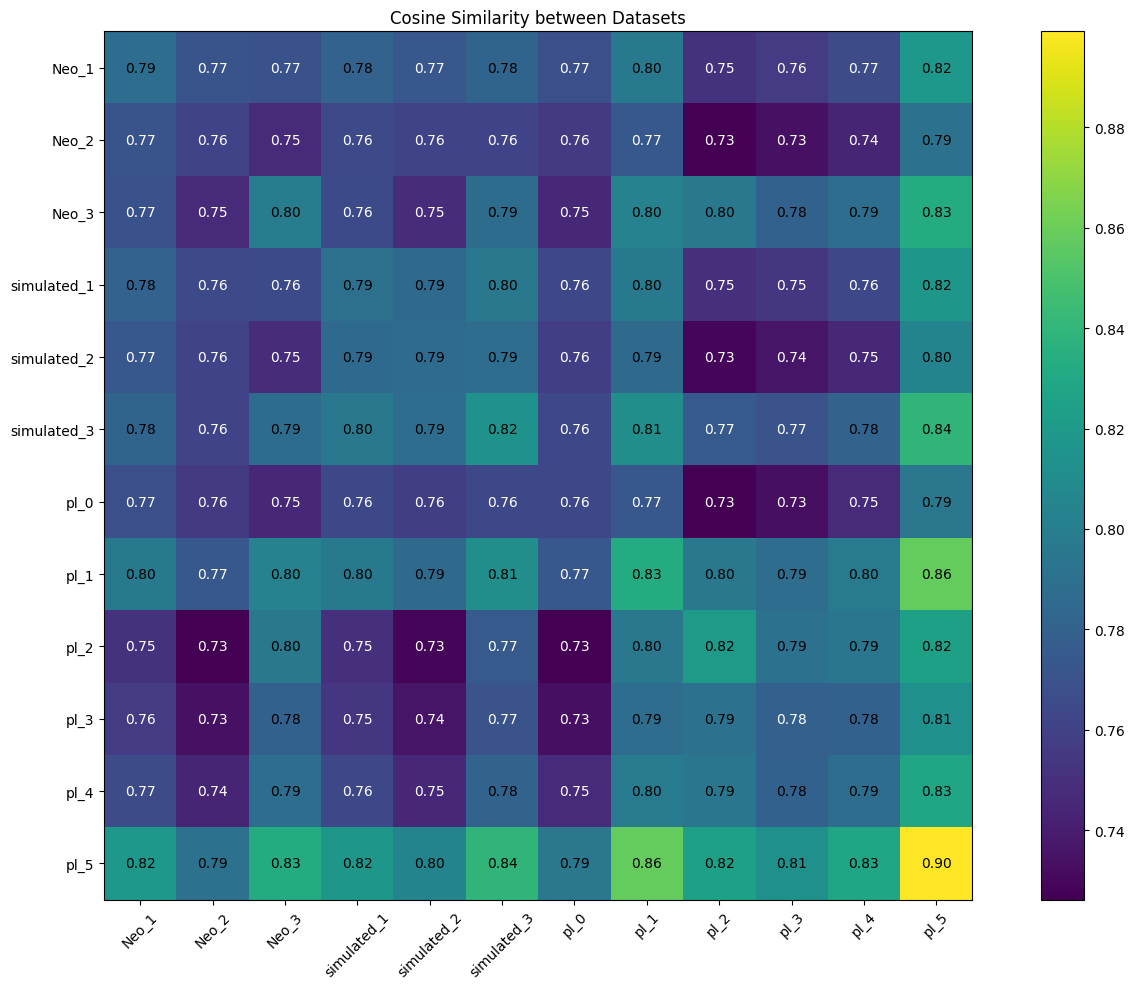


Average Cosine Similarity scores against Pléiades datasets:
Neo_1: nan
Neo_2: nan
Neo_3: nan
simulated_1: nan
simulated_2: nan
simulated_3: nan
pl_0: nan
pl_1: nan
pl_2: nan
pl_3: nan
pl_4: nan
pl_5: nan


/home/thomas/miniconda3/envs/sam3_env/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/thomas/miniconda3/envs/sam3_env/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [10]:
### COSINE SIMILARITY COMPUTATION

from sklearn.metrics.pairwise import cosine_similarity

# Compute cosine similarity between each pair of datasets
similarity_results = np.zeros((nb_datasets, nb_datasets))
for i, (name_i, emb_i) in enumerate(datasets.items()):
    for j, (name_j, emb_j) in enumerate(datasets.items()):
        sim = cosine_similarity(emb_i, emb_j)
        similarity_results[i, j] = np.mean(sim) # Average similarity across all tile pairs

# Visualization
plot_matrix(similarity_results, list(datasets.keys()), title="Cosine Similarity between Datasets")

# Mean scores against Pléiades datasets
similarity_mean_scores = compute_mean_scores(similarity_results, list(datasets.keys()), prefix="S2")
print("\nAverage Cosine Similarity scores against Pléiades datasets:")
for name, score in similarity_mean_scores.items():
    print(f"{name}: {score:.4f}")

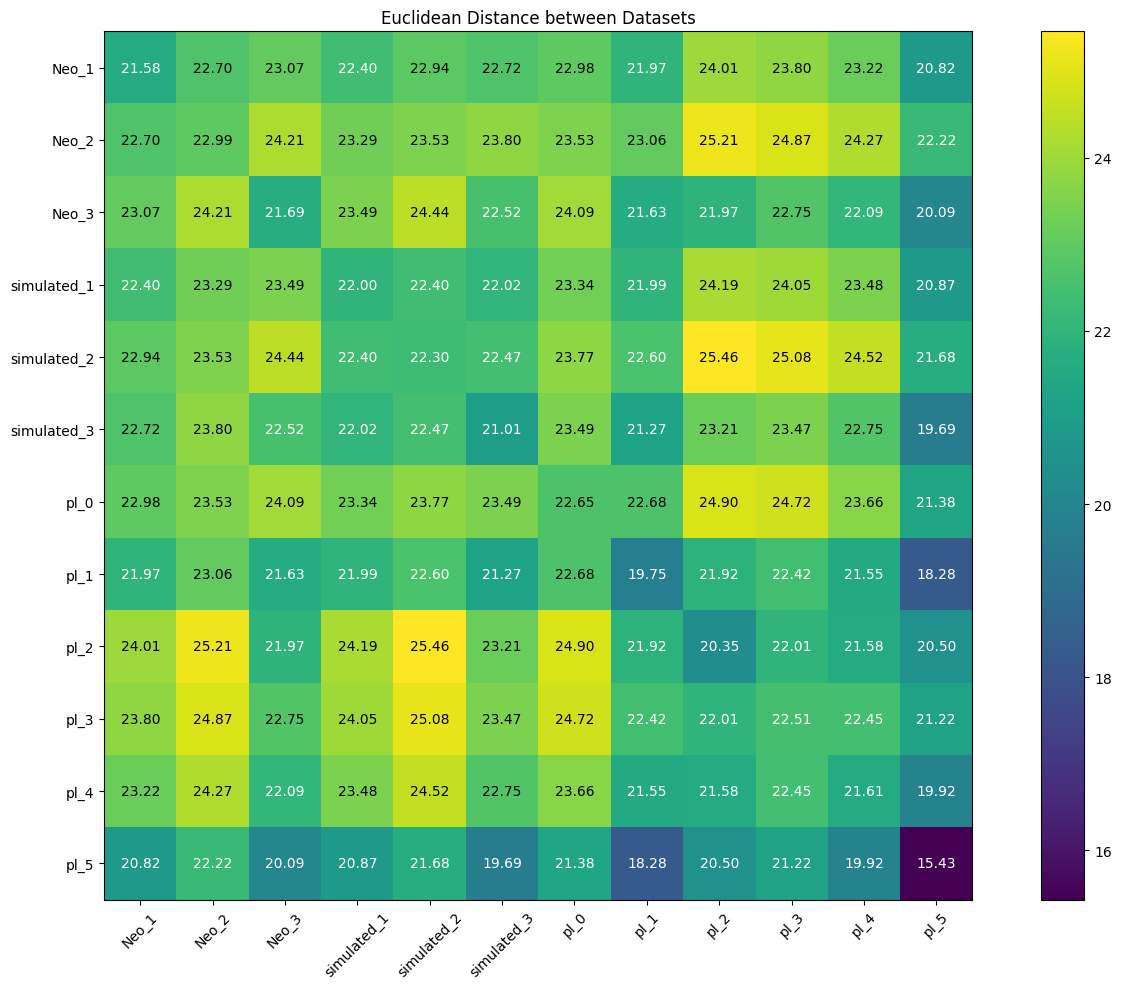


Average Euclidean Distance scores against Pléiades datasets:
Neo_1: nan
Neo_2: nan
Neo_3: nan
simulated_1: nan
simulated_2: nan
simulated_3: nan
pl_0: nan
pl_1: nan
pl_2: nan
pl_3: nan
pl_4: nan
pl_5: nan


/home/thomas/miniconda3/envs/sam3_env/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/thomas/miniconda3/envs/sam3_env/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [11]:
### EUCLIDEAN DISTANCE COMPUTATION

from sklearn.metrics.pairwise import euclidean_distances

# Compute euclidean distance between each pair of datasets
distance_results = np.zeros((nb_datasets, nb_datasets))
for i, (name_i, emb_i) in enumerate(datasets.items()):
    for j, (name_j, emb_j) in enumerate(datasets.items()):
        dist = euclidean_distances(emb_i, emb_j)
        distance_results[i, j] = np.mean(dist) # Average distance across all tile pairs

# Visualization
plot_matrix(distance_results, list(datasets.keys()), title="Euclidean Distance between Datasets")

# Mean scores against Pléiades datasets
distance_mean_scores = compute_mean_scores(distance_results, list(datasets.keys()), prefix="S2")
print("\nAverage Euclidean Distance scores against Pléiades datasets:")
for name, score in distance_mean_scores.items():
    print(f"{name}: {score:.4f}")

Aggregated 6000 total samples.
Computing UMAP projection... (Metric: Cosine)


/home/thomas/miniconda3/envs/sam3_env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


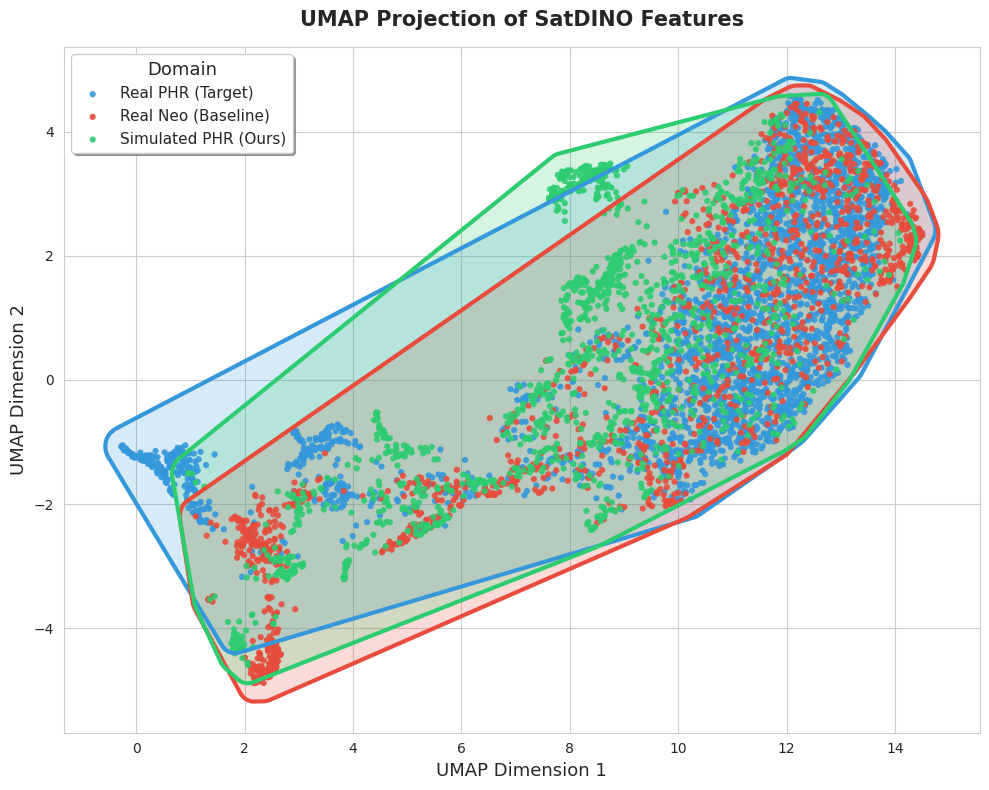

In [12]:
# ==========================================
# UMAP PROJECTION OF SATDINO EMBEDDINGS 
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap  
import torch
from scipy.spatial import ConvexHull
from shapely.geometry import Polygon # <--- NEW: Imported for smooth buffering

all_features = []
labels = []

# 1. Aggregate features using your specific dictionary keys
for key, emb in datasets.items():
    if key.startswith('Neo'):
        plot_label = 'Real Neo (Baseline)'
    elif key.startswith('simulated'):
        plot_label = 'Simulated PHR (Ours)'
    elif key.startswith('pl_'):
        # Group all Pléiades samples together
        plot_label = 'Real PHR (Target)'
    else:
        print(f"Skipping unmapped key: {key}")
        continue
        
    # Ensure it's a 2D numpy array (N_samples, 768)
    if torch.is_tensor(emb):
        emb = emb.cpu().numpy()
        
    all_features.append(emb)
    labels.extend([plot_label] * emb.shape[0])

# Stack into single arrays for UMAP
all_features = np.vstack(all_features)
labels = np.array(labels)

print(f"Aggregated {all_features.shape[0]} total samples.")

# 2. Compute UMAP Projection
print("Computing UMAP projection... (Metric: Cosine)")
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
projection = reducer.fit_transform(all_features)

# 3. Plot the Projection
plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")

# Distinct color palette for clear publication visuals
color_palette = {
    'Real Neo (Baseline)': '#e74c3c',   # Red
    'Real PHR (Target)': '#3498db',     # Blue
    'Simulated PHR (Ours)': '#2ecc71'   # Green
}

drawing_order = [
    'Real PHR (Target)',    
    'Real Neo (Baseline)',  
    'Simulated PHR (Ours)', 
]

ax = plt.gca()

# Calculate a dynamic padding distance based on the overall spread of the data
x_range = projection[:, 0].max() - projection[:, 0].min()
y_range = projection[:, 1].max() - projection[:, 1].min()
buffer_distance = max(x_range, y_range) * 0.02  # 2% of the plot size for padding

# ------------------------------------------------------------------
# PHASE 1: Draw Fills & Borders (Using Shapely Buffering)
# ------------------------------------------------------------------
for i, domain in enumerate(drawing_order):
    idx = np.where(labels == domain)[0]
    points = projection[idx]
    
    if len(points) >= 4:
        # Get the rigid outer boundary
        hull = ConvexHull(points)
        hull_points = points[hull.vertices]
        
        # Create a Shapely polygon and apply a smooth, rounded buffer (padding)
        poly = Polygon(hull_points)
        # join_style=1 means 'round', cap_style=1 means 'round'
        smooth_poly = poly.buffer(buffer_distance, join_style=1, cap_style=1)
        
        # Extract the smoothed coordinates
        x_new, y_new = smooth_poly.exterior.xy
        
        # Fills go at the absolute bottom (zorder 1, 2, 3)
        ax.fill(x_new, y_new, color=color_palette[domain], alpha=0.2, zorder=1 + i)
        
        # Borders go at the absolute top so they aren't hidden by dots (zorder 20, 21, 22)
        ax.plot(x_new, y_new, color=color_palette[domain], linewidth=3, linestyle='-', zorder=20 + i)

# ------------------------------------------------------------------
# PHASE 2: Draw Scatter Dots manually to force Z-order
# ------------------------------------------------------------------
for i, domain in enumerate(drawing_order):
    idx = np.where(labels == domain)[0]
    points = projection[idx]
    
    ax.scatter(
        x=points[:, 0], 
        y=points[:, 1], 
        c=color_palette[domain],
        label=domain,       
        alpha=0.9,          
        s=20,               
        edgecolors="none",
        zorder=10 + i       
    )

# Formatting for publication
plt.title("UMAP Projection of SatDINO Features", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("UMAP Dimension 1", fontsize=13)
plt.ylabel("UMAP Dimension 2", fontsize=13)
plt.legend(title="Domain", title_fontsize='13', fontsize='11', loc='best', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

In [13]:
import plotly.graph_objects as go
import ipywidgets as widgets
import matplotlib.pyplot as plt
from IPython.display import display
import numpy as np
from PIL import Image  
from scipy.spatial import ConvexHull
from shapely.geometry import Polygon

print("Step 1: Initializing FigureWidget, color palette, and buffer distance...")
fig = go.FigureWidget()

color_palette = {
    'Real Neo (Baseline)': '#e74c3c',
    'Real PHR (Target)': '#3498db',
    'Simulated PHR (Ours)': '#2ecc71'
}

# Helper function to convert Hex colors to RGBA for Plotly transparent fills
def hex_to_rgba(hex_color, alpha):
    hex_color = hex_color.lstrip('#')
    r, g, b = tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))
    return f'rgba({r},{g},{b},{alpha})'

# Calculate a dynamic padding distance based on the overall spread of the data
x_range = projection[:, 0].max() - projection[:, 0].min()
y_range = projection[:, 1].max() - projection[:, 1].min()
buffer_distance = max(x_range, y_range) * 0.02  # 2% of the plot size for padding

print("Step 2: Drawing smooth Shapely boundaries (Background Layer)...")
# --- PHASE 1: BACKGROUND POLYGONS ---
for domain in drawing_order:
    idx = np.where(labels == domain)[0]
    points = projection[idx]
    
    if len(points) >= 4:
        hull = ConvexHull(points)
        hull_points = points[hull.vertices]
        
        poly = Polygon(hull_points)
        smooth_poly = poly.buffer(buffer_distance, join_style=1, cap_style=1)
        x_new, y_new = smooth_poly.exterior.xy
        
        fig.add_trace(go.Scatter(
            x=list(x_new),
            y=list(y_new),
            mode='lines',
            fill='toself',
            fillcolor=hex_to_rgba(color_palette[domain], 0.2), 
            line=dict(color=color_palette[domain], width=3),   
            name=domain + " Boundary",
            hoverinfo='skip', 
            showlegend=False  
        ))

print("Step 3: Adding interactive scatter points (Foreground Layer)...")
# --- PHASE 2: SCATTER POINTS ---
for domain in drawing_order:
    idx = np.where(labels == domain)[0]
    print(f"  -> Adding {len(idx)} clickable points for '{domain}'...")
    
    fig.add_trace(go.Scatter(
        x=projection[idx, 0],
        y=projection[idx, 1],
        mode='markers',
        name=domain,
        marker=dict(color=color_palette[domain], size=6, opacity=0.8),
        customdata=idx 
    ))

print("Step 4: Updating figure layout...")
fig.update_layout(
    title="Interactive UMAP: Click a dot to view the tile",
    xaxis_title="UMAP Dimension 1",
    yaxis_title="UMAP Dimension 2",
    width=800,
    height=650,
    template="plotly_white",
    hovermode="closest"
)

print("Step 5: Creating the dynamic output widget...")
out = widgets.Output(layout=widgets.Layout(
    width='450px', 
    height='580px',  # Increased slightly to fit the 3 lines of RGB stats
    border='1px solid #ccc',
    margin='50px 0 0 20px'
))

with out:
    print("Click any point on the UMAP to load the corresponding tile here.")

# --- CALLBACK LOGIC ---
def on_click_point(trace, points, selector):
    if not points.point_inds:
        return
    
    trace_idx = points.point_inds[0]
    global_idx = trace.customdata[trace_idx]
    
    out.clear_output(wait=True)
    
    with out:
        print(f"[Callback Triggered] Trace: {trace.name} | Global Index: {global_idx}")
        try:
            print(f"  -> Fetching image array for index {global_idx}...")
            tile_image = all_sampled_tiles[global_idx]
            
            # --- NEW: Calculate and Print RGB Pixel Stats ---
            # tile_image is (H, W, C). Slice by the last axis to get R, G, B bands
            r_min, r_max = np.min(tile_image[:, :, 0]), np.max(tile_image[:, :, 0])
            g_min, g_max = np.min(tile_image[:, :, 1]), np.max(tile_image[:, :, 1])
            b_min, b_max = np.min(tile_image[:, :, 2]), np.max(tile_image[:, :, 2])
            
            print("  -> RGB Pixel Stats:")
            print(f"       Red   | Min: {r_min:8.2f}, Max: {r_max:8.2f}")
            print(f"       Green | Min: {g_min:8.2f}, Max: {g_max:8.2f}")
            print(f"       Blue  | Min: {b_min:8.2f}, Max: {b_max:8.2f}")
            # ------------------------------------------------
            
            print(f"  -> Rendering image using matplotlib...")
            fig_img, ax_img = plt.subplots(figsize=(4, 4))
            ax_img.imshow(tile_image)
            ax_img.axis('off')
            ax_img.set_title(f"{labels[global_idx]} \n Index: {global_idx}")
            plt.show()
            
            # --- 'Open in OS' button ---
            open_btn = widgets.Button(
                description='Open in PC Viewer',
                button_style='info', 
                icon='external-link'
            )
            
            def open_in_os(b):
                img_array = tile_image
                if img_array.dtype != np.uint8:
                    if img_array.max() <= 1.0:
                        img_array = (img_array * 255).astype(np.uint8)
                    else:
                        img_array = img_array.astype(np.uint8)
                
                img_pil = Image.fromarray(img_array)
                img_pil.show()
                
            open_btn.on_click(open_in_os)
            display(open_btn)
            
            print(f"  -> Done rendering.")
        except Exception as e:
            print(f"Error loading image index {global_idx}. Did you save the tiles?")
            print(e)

print("Step 6: Attaching click callbacks to scatter traces...")
# Attach the callback ONLY to the scatter markers
for trace in fig.data:
    if trace.mode == 'markers': 
        trace.on_click(on_click_point)

print("Step 7: Displaying the UMAP and Image Output side-by-side...")
display(widgets.HBox([fig, out]))
print("Done! Waiting for user interaction...")

Step 1: Initializing FigureWidget, color palette, and buffer distance...
Step 2: Drawing smooth Shapely boundaries (Background Layer)...
Step 3: Adding interactive scatter points (Foreground Layer)...
  -> Adding 3000 clickable points for 'Real PHR (Target)'...
  -> Adding 1500 clickable points for 'Real Neo (Baseline)'...
  -> Adding 1500 clickable points for 'Simulated PHR (Ours)'...
Step 4: Updating figure layout...
Step 5: Creating the dynamic output widget...
Step 6: Attaching click callbacks to scatter traces...
Step 7: Displaying the UMAP and Image Output side-by-side...


    'data': [{'fill': 'toself',
              'fillcolor': 'rgba(52,152,219,0.2)…

Done! Waiting for user interaction...
